# Counter Strike Case Values Linear Regression Pricing Model



In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score
import sklearn as sk



c:\Users\romeo\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [3]:
# Step 1 Pick your data. Grab historical price data for one asset

data = pd.read_csv("Weapons_Case_Price_Data_CSGO.csv")
df = pd.DataFrame(data)
df.rename(columns={'Price (USD)': 'Price'}, inplace=True)
print(df.head())


                 Date  Price  Volume
0  Aug 14 2013 01: +0  8.528      38
1  Aug 15 2013 01: +0  5.436    5412
2  Aug 16 2013 01: +0  3.351    9877
3  Aug 17 2013 01: +0  2.621   11050
4  Aug 18 2013 01: +0  2.665   11485


In [4]:
# Inputs for the linear regression model
name = input("Enter the name of the asset: ")
moving_average_window = int(input("Enter the moving average window size (Calculation): "))
volatility_window = int(input("Enter the volatility window size (Calculation): "))



In [ ]:
#Step 2 — Engineer your features. Transform price into things like daily returns 


df['Daily_Return'] = df['Price'].pct_change().shift(1)
df['Daily_Return'].fillna(0, inplace=True)  # Handle the NaN

## Add more features if needed, like moving averages, volatility, etc.
df['Moving_Average'] = df['Price'].rolling(window=moving_average_window).mean().shift(1)  # Shift to avoid look-ahead bias
df['Volatility'] = df['Price'].rolling(window=volatility_window).std().shift(1)
df.dropna(inplace=True)  # Drop rows with NaN values from rolling calculations

# Step 3 — Train your model. Use linear regression to find the best fit line for your data
X = df[['Daily_Return', 'Moving_Average', 'Volatility']]
y = df['Price']
model = LinearRegression()
model.fit(X, y)




C:\Users\romeo\AppData\Local\Temp\ipykernel_3940\1411615709.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Daily_Return'].fillna(0, inplace=True)  # Handle the NaN


LinearRegression()

In [6]:
# Step 4 — Evaluate your model. Check how well it fits the data using metrics like R-squared
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)
print(f"R-squared: {r2}")


R-squared: 0.9719252428770477


Actual Price: 224.13
Predicted Price: 219.33760699758147
R-squared: 0.9719252428770477


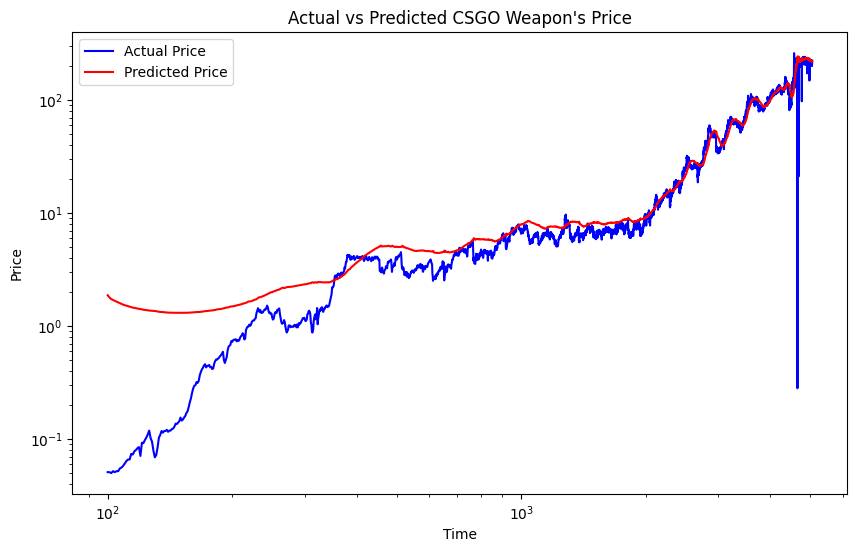

In [7]:
# Plotting the actual vs predicted prices
print(f"Actual Price: {y.iloc[-1]}")
print(f"Predicted Price: {y_pred[-1]}")
print(f"R-squared: {r2}")


plt.figure(figsize=(10, 6))
plt.loglog(df.index, y, color='blue', label='Actual Price')
plt.loglog(df.index, y_pred, color='red', label='Predicted Price')
plt.title(f"Actual vs Predicted {name}'s Price")
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

## GARCH Modeling

Std before cleaning: 1155.45%
Std after cleaning:  3.50%
Max before: 81360.99%  Max after: 11.09%

GARCH(1,1) Volatility Forecast — next 5 days (in %):
h.1    2.657646
h.2    2.670996
h.3    2.684178
h.4    2.697193
h.5    2.710046
GARCH(1, 1) Model Summary:
                        Constant Mean - GARCH Model Results                         
Dep. Variable:           Daily_Return_Clean   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -12799.8
Distribution:      Standardized Student's t   AIC:                           25609.5
Method:                  Maximum Likelihood   BIC:                           25642.1
                                              No. Observations:                 4959
Date:                      Tue, May 05 2026   Df Residuals:                     4958
Time:                              15:00:48   Df Model:      

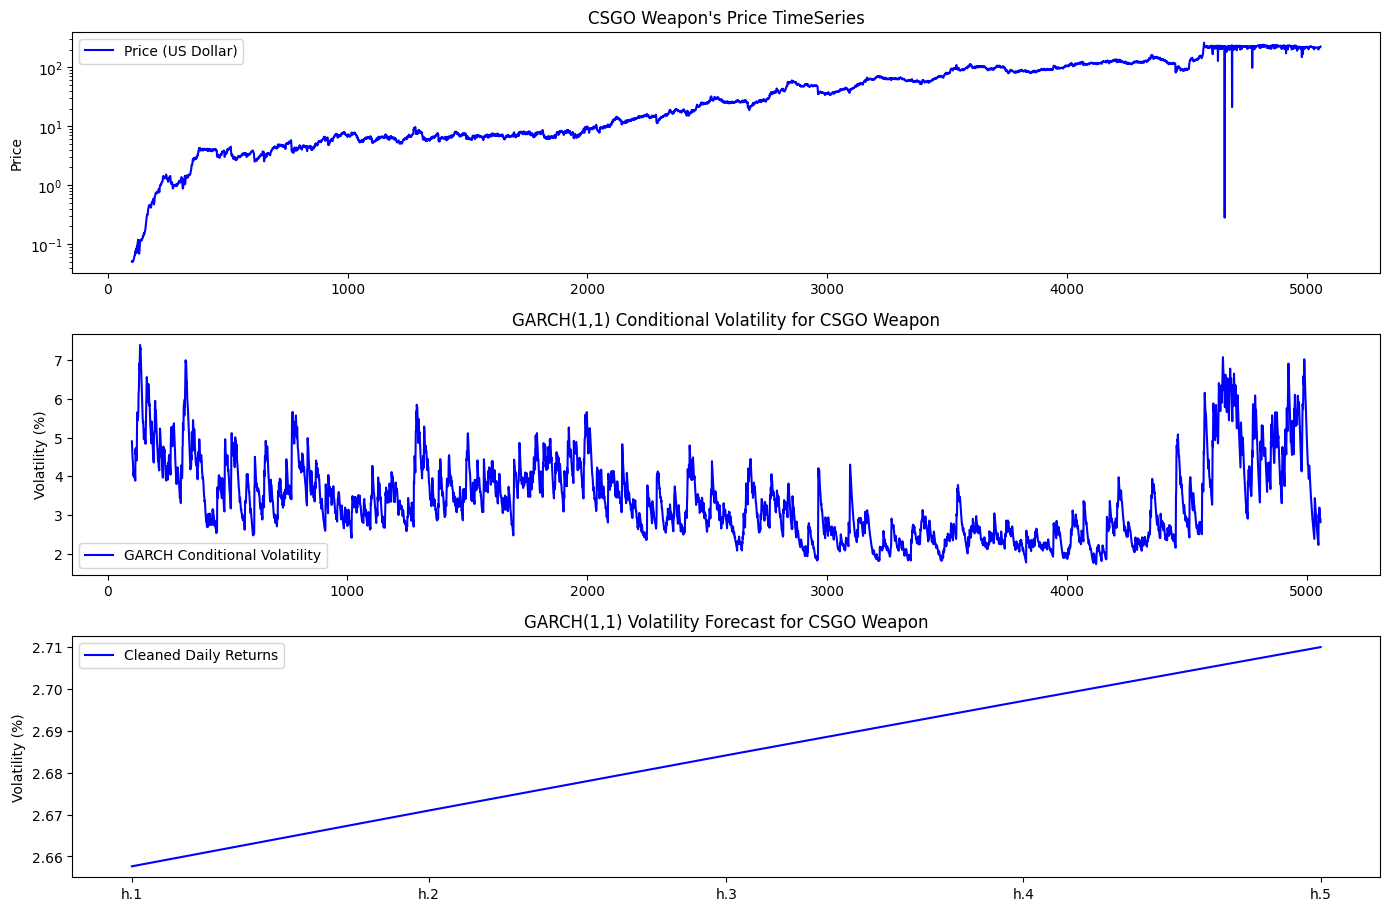

In [26]:
from arch import arch_model
import numpy as np

# --- Fix 1: Clean the returns properly ---
df['Daily_Return'] = df['Price'].pct_change()
df['Daily_Return'] = df['Daily_Return'].fillna(0)  # Fix pandas CoW warning


df['Daily_Return_Pct'] = df['Daily_Return'] * 100

# --- Fix 2: Winsorize outliers (cap extreme values) ---
lower = df['Daily_Return_Pct'].quantile(0.01)
upper = df['Daily_Return_Pct'].quantile(0.99)
df['Daily_Return_Clean'] = df['Daily_Return_Pct'].clip(lower, upper)

print(f"Std before cleaning: {df['Daily_Return_Pct'].std():.2f}%")
print(f"Std after cleaning:  {df['Daily_Return_Clean'].std():.2f}%")
print(f"Max before: {df['Daily_Return_Pct'].max():.2f}%  Max after: {df['Daily_Return_Clean'].max():.2f}%")

# --- Fix 3: Fit GARCH on the clean, scaled returns ---
garch_model = arch_model(
    df['Daily_Return_Clean'],
    vol='Garch',
    p=1, q=1,
    dist='t'          # We use T because the distribution of returns often has fat tails (extreme events are more common than normal distribution would suggest
)
garch_fit = garch_model.fit(disp='off')

# --- Forecast ---
garch_forecast = garch_fit.forecast(horizon=5)
forecast_variance = garch_forecast.variance.iloc[-1]
forecast_vol = np.sqrt(forecast_variance)

print("\nGARCH(1,1) Volatility Forecast — next 5 days (in %):")
print(forecast_vol.to_string())

# --- Add vol forecast as a feature for your linear model ---
# Use TODAY's conditional volatility as a feature (no lookahead)
df['GARCH_Vol'] = garch_fit.conditional_volatility
df['GARCH_Vol'] = df['GARCH_Vol'].shift(1)
print("GARCH(1, 1) Model Summary:")
print(garch_fit.summary())
#Print GARCH Table


# Plot GARCH volatility forecast
plt.figure(figsize=(14, 12))
plt.subplot(4, 1, 1)
plt.plot(df["Price"], color='blue', label='Price (US Dollar)')
plt.yscale('log')
plt.title(f"{name}'s Price TimeSeries")
plt.ylabel('Price')
plt.legend()
plt.tight_layout()

plt.subplot(4, 1, 2)
plt.plot(df['GARCH_Vol'], color='blue', label='GARCH Conditional Volatility')
plt.title(f"GARCH(1,1) Conditional Volatility for {name}")
plt.ylabel('Volatility (%)')
plt.legend()
plt.tight_layout()

plt.subplot(4, 1, 3)
plt.plot(forecast_vol, color='blue', label='Cleaned Daily Returns')
plt.title(f"GARCH(1,1) Volatility Forecast for {name}")
plt.ylabel('Volatility (%)')
plt.legend()
plt.tight_layout()
plt.show()



In [9]:
# Garch Model Interpretation
# R Squared: The R-squared value indicates how well the linear regression model fits the data. 
# Mu: Average return of the asset. A positive mu suggests an upward trend, while a negative mu indicates a downward trend.
# Coe Std T used for confidence intervals: These values help determine the statistical significance of the coefficients.
# P > |t|: A low p-value (typically < 0.05) indicates that the coefficient is statistically significant, meaning it has a meaningful impact on the price.
# P < 0.05: If the p-value is less than 0.05, it suggests that the corresponding feature is statistically significant in predicting the price.
# Confidence Intervals: If the confidence interval for a coefficient does not include zero, it suggests that the feature has a statistically significant impact on the price.
# omega: The omega parameter represents the long-term average volatility. A higher omega indicates a higher baseline level of volatility.
#alpha[1]: The alpha parameter represents the short-term volatility response to shocks. A higher alpha indicates that volatility reacts more strongly to recent returns.
# beta[1]: The beta parameter represents the persistence of volatility. A higher beta indicates that





ValueError: x and y must have same first dimension, but have shapes (4959,) and (1,)

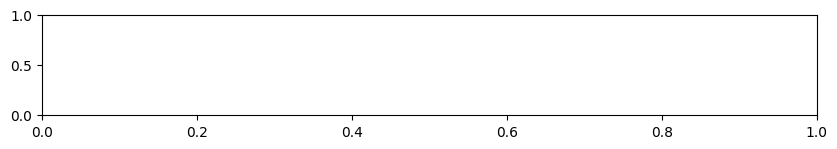